In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import glob
import re
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font)

In [2]:
def load_fidelity_data(pattern):
    """ Loads time series data (fidelity vs. tau for fixed delta). """
    file_list = glob.glob(pattern)
    print(f"Searching for '{pattern}': Found {len(file_list)} files.")
    data = []
    for filename in file_list:
        match = re.search(r'delta_([\d.]+)\.CSV', filename)
        if match:
            delta_value = float(match.group(1))
            fidelity_values = np.loadtxt(filename)
            if fidelity_values.shape == (200,):
                data.append({'delta': delta_value, 'fidelities': fidelity_values})
    return data


In [ ]:
def create_and_plot_full_visualization():
    # --- 1. File Patterns and Loading ---
    pattern_lr_ts = "fidel_vs_delta_data/fidelLR_kitaev_n_60_tau_120.0_delta_*.CSV"
    pattern_ma_ts = "fidel_vs_delta_data/fidelMA_kitaev_n_60_tau_120.0_delta_*.CSV"
    file_lr_vs_delta = "fidel_vs_delta_data/fidelLR_vs_delta_tau_60.csv"
    file_ma_vs_delta = "fidel_vs_delta_data/fidelMA_vs_delta_tau_60.csv"

    data_lr_ts = load_fidelity_data(pattern_lr_ts)
    data_ma_ts = load_fidelity_data(pattern_ma_ts)
    
    deltas_fs_axis = np.linspace(0.1, 1.0, 200)
    data_lr_fs, data_ma_fs = None, None
    
    if os.path.exists(file_lr_vs_delta):
        fidelities = np.loadtxt(file_lr_vs_delta)
        if fidelities.shape == (200,):
            data_lr_fs = np.c_[deltas_fs_axis, fidelities]
            print(f"Loaded '{file_lr_vs_delta}' and mapped to delta axis.")
            
    if os.path.exists(file_ma_vs_delta):
        fidelities = np.loadtxt(file_ma_vs_delta)
        if fidelities.shape == (200,):
            data_ma_fs = np.c_[deltas_fs_axis, fidelities]
            print(f"Loaded '{file_ma_vs_delta}' and mapped to delta axis.")

    if not data_lr_ts and not data_ma_ts and data_lr_fs is None and data_ma_fs is None:
        print("\n❌ No data files found.")
        # Tip: Uncomment the line below to generate dummy files for testing.
        # generate_all_dummy_files()
        return

    # --- 2. Filter Data by Delta Limit ---
    delta_limit = 1.0
    data_lr_ts = [item for item in data_lr_ts if item['delta'] <= delta_limit]
    data_ma_ts = [item for item in data_ma_ts if item['delta'] <= delta_limit]
    if data_lr_fs is not None: data_lr_fs = data_lr_fs[data_lr_fs[:, 0] <= delta_limit]
    if data_ma_fs is not None: data_ma_fs = data_ma_fs[data_ma_fs[:, 0] <= delta_limit]
    print(f"\nℹ️  Note: Plotting data only for delta <= {delta_limit}.")

    # --- 3. Setup Custom Diverging Colormap ---
    deltas_ts = [item['delta'] for item in data_lr_ts] + [item['delta'] for item in data_ma_ts]
    deltas_fs_lr = data_lr_fs[:, 0] if data_lr_fs is not None and data_lr_fs.ndim > 1 else []
    deltas_fs_ma = data_ma_fs[:, 0] if data_ma_fs is not None and data_ma_fs.ndim > 1 else []
    all_deltas = np.concatenate([deltas_ts, deltas_fs_lr, deltas_fs_ma])

    if len(all_deltas) == 0:
        print("❌ No data left to plot after filtering. Exiting.")
        return

    d_min, d_max = min(all_deltas), max(all_deltas)
    colors = ["blue", "black", "red"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_bkr", colors)
    diverging_norm = mcolors.TwoSlopeNorm(vmin=d_min, vcenter=0.5, vmax=d_max)
    
    # --- 4. Create the 3D Plot ---
    print("🚀 Generating final 3D visualization...")
    fig = plt.figure(figsize=(9, 7), dpi=600)
    ax = fig.add_subplot(111, projection='3d')
    times_tau = np.linspace(0.5, 120, 200)

    # --- 5. Plot Time Series Lines ---
    for item in sorted(data_lr_ts, key=lambda x: x['delta']):
        ax.plot(np.full_like(times_tau, item['delta']), times_tau, item['fidelities'],
                color=custom_cmap(diverging_norm(item['delta'])), linestyle='--', linewidth=1.5)
    for item in sorted(data_ma_ts, key=lambda x: x['delta']):
        ax.plot(np.full_like(times_tau, item['delta']), times_tau, item['fidelities'],
                color=custom_cmap(diverging_norm(item['delta'])), linestyle='-', linewidth=1.5)

    # --- 6. Plot the Reference Plane and Orthogonal Lines ---
    plane_tau = 65
    
    xx, zz = np.meshgrid([d_min, d_max], [0, 1])
    yy = np.full_like(xx, plane_tau)
    ax.plot_surface(xx, yy, zz, color='gray', alpha=0.3)

    # --- Use a loop with ax.plot() for orthogonal lines ---
    # Plot Orthogonal LR line (dashed by skipping segments)
    if data_lr_fs is not None:
        deltas, fidelities = data_lr_fs[:, 0], data_lr_fs[:, 1]
        # UPDATED: Loop with a step of 6 to plot 2 segments and skip 4
        for i in range(0, len(deltas) - 2, 6):
            segment_color = custom_cmap(diverging_norm(deltas[i]))
            # Plot a 2-segment chunk (3 points)
            ax.plot(deltas[i:i+3], [plane_tau]*3, fidelities[i:i+3],
                    color=segment_color, 
                    linestyle='-',
                    linewidth=2.5)

    # Plot Orthogonal MA line (solid)
    if data_ma_fs is not None:
        deltas, fidelities = data_ma_fs[:, 0], data_ma_fs[:, 1]
        for i in range(len(deltas) - 1):
            segment_color = custom_cmap(diverging_norm(deltas[i]))
            ax.plot(deltas[i:i+2], [plane_tau, plane_tau], fidelities[i:i+2],
                    color=segment_color, linestyle='-', linewidth=2.5)

    # --- 7. Customize Plot ---
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=diverging_norm)
    #cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', location='bottom',
                        #pad=0.1, shrink=0.25, aspect=40)
    #cbar.set_label('$\Delta$', size=12)
    legend_elements = [
        Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label='Minimal Action'),
        Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label='Linear Ramp')]
    #ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
    ax.set_xlabel('$\Delta$', fontsize=14, labelpad=15)
    ax.set_ylabel(r'$\tau$', fontsize=14, labelpad=15)
    ax.set_zlabel('$\mathcal{F}$', fontsize=14, labelpad=15, rotation = 180)
    #ax.set_title('Fidelity vs. Time and Delta (n=60)', fontsize=18, pad=20)
    ax.view_init(elev=20, azim=-135)
    ax.set_box_aspect(None, zoom=0.8)
    plt.show()


<>:106: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8267/2723291532.py:106: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('$\Delta$', fontsize=14, labelpad=15)
/tmp/ipykernel_8267/2723291532.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$\mathcal{F}$', fontsize=14, labelpad=15, rotation = 180)


Searching for 'fidelLR_kitaev_n_60_tau_120.0_delta_*.CSV': Found 16 files.
Searching for 'fidelMA_kitaev_n_60_tau_120.0_delta_*.CSV': Found 16 files.
Loaded 'fidelLR_vs_delta_tau_60.csv' and mapped to delta axis.
Loaded 'fidelMA_vs_delta_tau_60.csv' and mapped to delta axis.

ℹ️  Note: Plotting data only for delta <= 1.0.
🚀 Generating final 3D visualization...


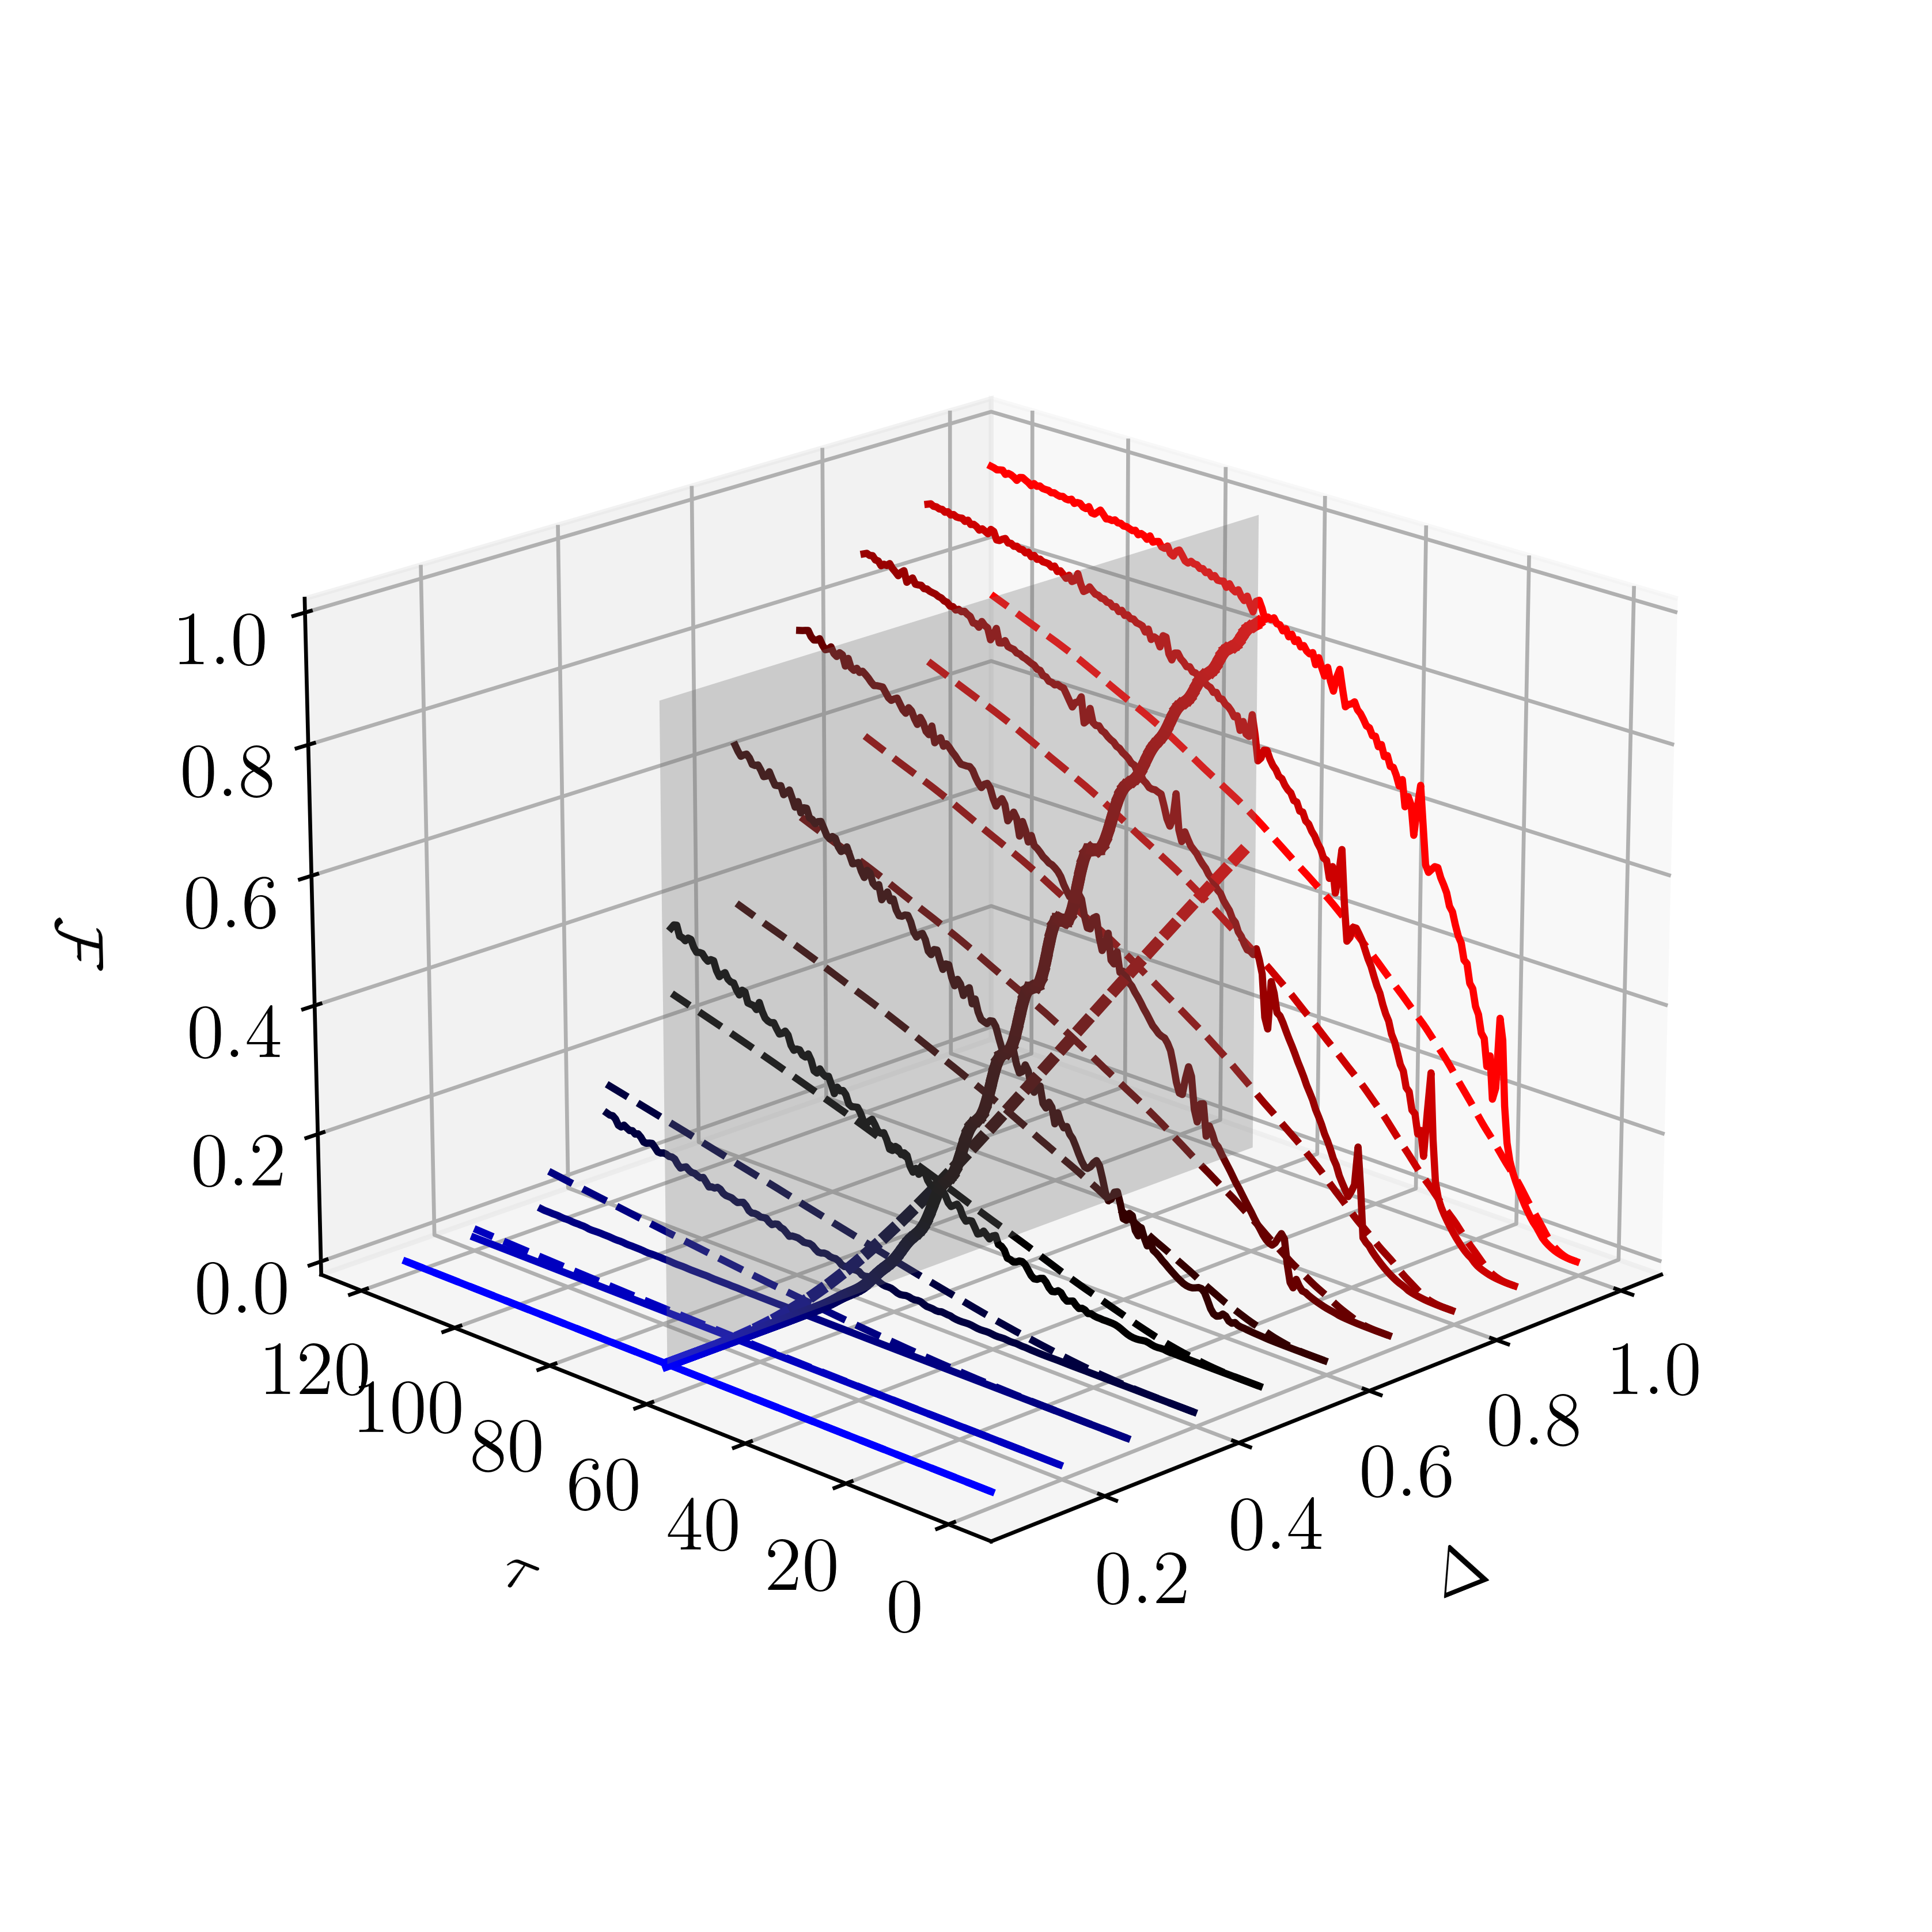

In [4]:
if __name__ == '__main__':
    create_and_plot_full_visualization()